In [1]:
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import sys
sys.path.append('/app')

import tensorflow as tf
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from src.data.dataset import create_dataset

print("✓ Módulos cargados")

2026-02-10 18:50:51.481650: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-10 18:50:51.481703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-10 18:50:51.482971: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✓ Módulos cargados


In [2]:
# Cargar modelo
model = tf.keras.models.load_model('/app/models/checkpoints/best_model.h5')

print("✓ Modelo cargado")

# Cargar test set
TEST_PATH = Path('/app/data/raw/Test_Set/Test_Set')
test_df = pd.read_csv(TEST_PATH / 'RFMiD_Testing_Labels.csv')

print(f"✓ Test set: {len(test_df)} imágenes")

✓ Modelo cargado
✓ Test set: 640 imágenes


In [3]:
test_dataset = create_dataset(
    df=test_df,
    img_dir=TEST_PATH / 'Test',
    batch_size=32,
    shuffle=False,
    augment=False,
    filter_name='ben_graham'
)

print("✓ Test dataset creado")

✓ Test dataset creado


In [4]:
# Evaluar
results = model.evaluate(test_dataset, verbose=1)

print(f"\n{'='*50}")
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"{'='*50}")

20/20 [==============================] - 38s 2s/step - loss: 0.4733 - accuracy: 0.7375 - sparse_accuracy: 0.7375

Test Loss: 0.4733
Test Accuracy: 0.7375


In [5]:
# Obtener predicciones
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"✓ {len(y_true)} predicciones obtenidas")

✓ 640 predicciones obtenidas


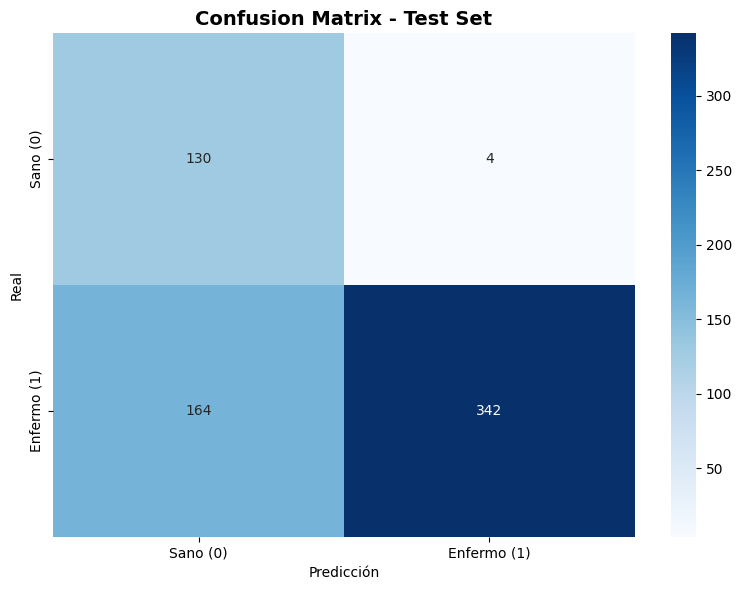


Confusion Matrix:
[[130   4]
 [164 342]]


In [6]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sano (0)', 'Enfermo (1)'],
            yticklabels=['Sano (0)', 'Enfermo (1)'])
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(cm)

In [7]:
# Report detallado
print("\nClassification Report:")
print("="*60)
print(classification_report(y_true, y_pred, 
                          target_names=['Sano (0)', 'Enfermo (1)'],
                          digits=4))


Classification Report:
              precision    recall  f1-score   support

    Sano (0)     0.4422    0.9701    0.6075       134
 Enfermo (1)     0.9884    0.6759    0.8028       506

    accuracy                         0.7375       640
   macro avg     0.7153    0.8230    0.7051       640
weighted avg     0.8741    0.7375    0.7619       640



In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

print(f"\n{'='*60}")
print("MÉTRICAS POR CLASE")
print(f"{'='*60}")
print(f"{'Clase':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print(f"{'-'*60}")
print(f"{'Sano (0)':<15} {precision[0]:<12.4f} {recall[0]:<12.4f} {f1[0]:<12.4f}")
print(f"{'Enfermo (1)':<15} {precision[1]:<12.4f} {recall[1]:<12.4f} {f1[1]:<12.4f}")
print(f"{'='*60}")


MÉTRICAS POR CLASE
Clase           Precision    Recall       F1-Score    
------------------------------------------------------------
Sano (0)        0.4422       0.9701       0.6075      
Enfermo (1)     0.9884       0.6759       0.8028      
